# 📘 CUSTOMER CHURN — ONE CSV COMPLETE MACHINE TEST REFERENCE

**This version uses ONLY ONE CSV file.**

The workflow is:

**Load one CSV → Inspect → Clean → EDA → Feature Engineering → Separate X/y → Train/Validation Split → Encoding → Scaling → 3 Models → Evaluation → GridSearchCV → Final Model → Save `.pkl` files → Streamlit / Flask deployment**

This is an exam-reference notebook. The code is written so that, when the exam gives a different CSV, you mainly change the file name, target name, and column names if necessary.


## 1. IMPORT LIBRARIES

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

import joblib

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

RANDOM_STATE = 42


## 2. LOAD THE SINGLE CSV

**Only one CSV is used.**

If the exam gives a different filename, change only `FILE_PATH`.


In [45]:
# Google Colab:
# Upload the CSV first using:
# from google.colab import files
# uploaded = files.upload()

data = pd.read_csv('Customer_Churn_Practice.csv')

print("Shape:", data.shape)
data.head()


Shape: (1200, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,CUST10000,Male,0,No,No,49,Yes,No,DSL,No,Yes,Yes,Yes,No,No,Month-to-month,Yes,Bank transfer,39.90,1720.39,Yes
1,CUST10001,Female,0,No,No,14,Yes,No,DSL,No,No,Yes,Yes,No,Yes,Month-to-month,Yes,Mailed check,48.39,573.85,No
2,CUST10002,Female,1,Yes,Yes,5,Yes,Yes,Fiber optic,Yes,No,Yes,No,Yes,Yes,Month-to-month,No,Bank transfer,90.98,572.92,No
3,CUST10003,Male,0,No,No,58,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Mailed check,22.95,1491.16,No
4,CUST10004,Male,1,No,Yes,61,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Electronic check,27.19,1722.11,No


## 3. BASIC DATA UNDERSTANDING

In [46]:
data.shape


(1200, 21)

In [47]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        1200 non-null   object 
 1   gender            1180 non-null   object 
 2   SeniorCitizen     1200 non-null   int64  
 3   Partner           1200 non-null   object 
 4   Dependents        1200 non-null   object 
 5   tenure            1200 non-null   int64  
 6   PhoneService      1200 non-null   object 
 7   MultipleLines     1200 non-null   object 
 8   InternetService   1200 non-null   object 
 9   OnlineSecurity    1183 non-null   object 
 10  OnlineBackup      1200 non-null   object 
 11  DeviceProtection  1200 non-null   object 
 12  TechSupport       1200 non-null   object 
 13  StreamingTV       1200 non-null   object 
 14  StreamingMovies   1200 non-null   object 
 15  Contract          1200 non-null   object 
 16  PaperlessBilling  1200 non-null   object 


In [48]:
data.describe()


,SeniorCitizen,tenure,MonthlyCharges
count,1200.000000,1200.000000,1175.000000
mean,0.178333,36.171667,56.970000
std,0.382953,21.127490,22.979454
min,0.000000,0.000000,18.000000
25%,0.000000,18.000000,38.110000
50%,0.000000,36.000000,57.400000
75%,0.000000,54.250000,77.340000
max,1.000000,72.000000,111.420000


In [49]:
data["Churn"].value_counts(dropna=False)


Churn
No     1117
Yes      83
Name: count, dtype: int64

## 4. DATA QUALITY CHECK — MISSING VALUES, DUPLICATES, BLANKS

In [50]:
print("Missing values:")
display(data.isnull().sum().sort_values(ascending=False))

print("Duplicate rows:", data.duplicated().sum())
print("Duplicate customer IDs:", data["customerID"].duplicated().sum())

blank_counts = data.astype("string").apply(lambda col: col.str.strip().eq("").sum())
print("Blank strings:")
display(blank_counts[blank_counts > 0])


Missing values:


MonthlyCharges      25
TotalCharges        22
gender              20
OnlineSecurity      17
customerID           0
Dependents           0
Partner              0
SeniorCitizen        0
tenure               0
InternetService      0
OnlineBackup         0
MultipleLines        0
PhoneService         0
TechSupport          0
DeviceProtection     0
StreamingTV          0
StreamingMovies      0
PaperlessBilling     0
Contract             0
PaymentMethod        0
Churn                0
dtype: int64

Duplicate rows: 0
Duplicate customer IDs: 0
Blank strings:


gender            3
OnlineSecurity    3
TotalCharges      3
dtype: int64

## 5. CLEAN OBVIOUS DATA ISSUES

Convert blank strings to `NaN` and convert numeric columns to numeric.

Do not automatically delete every outlier. First inspect whether it is a genuine observation or an error.


In [51]:
data = data.copy()

# Blank/whitespace values -> NaN
data = data.replace(r"^\s*$", np.nan, regex=True)

# Numeric conversion
data["MonthlyCharges"] = pd.to_numeric(data["MonthlyCharges"], errors="coerce")
data["TotalCharges"] = pd.to_numeric(data["TotalCharges"], errors="coerce")
data["tenure"] = pd.to_numeric(data["tenure"], errors="coerce")
data["SeniorCitizen"] = pd.to_numeric(data["SeniorCitizen"], errors="coerce")

print(data.isnull().sum().sort_values(ascending=False))


MonthlyCharges      25
TotalCharges        25
gender              23
OnlineSecurity      20
customerID           0
Dependents           0
Partner              0
SeniorCitizen        0
tenure               0
InternetService      0
OnlineBackup         0
MultipleLines        0
PhoneService         0
TechSupport          0
DeviceProtection     0
StreamingTV          0
StreamingMovies      0
PaperlessBilling     0
Contract             0
PaymentMethod        0
Churn                0
dtype: int64


## 6. MISSING-VALUE TREATMENT

For this exam reference:
- categorical columns → mode
- numerical columns → median

The values are calculated before modelling. For a stricter production workflow, fit imputers on training data only.


In [52]:
categorical_cols_all = data.select_dtypes(include="object").columns.tolist()
numeric_cols_all = data.select_dtypes(include=np.number).columns.tolist()

for col in categorical_cols_all:
    if data[col].isnull().any():
        data[col] = data[col].fillna(data[col].mode()[0])

for col in numeric_cols_all:
    if data[col].isnull().any():
        data[col] = data[col].fillna(data[col].median())

print("Remaining missing values:", data.isnull().sum().sum())


Remaining missing values: 0


## 7. OUTLIER CHECK

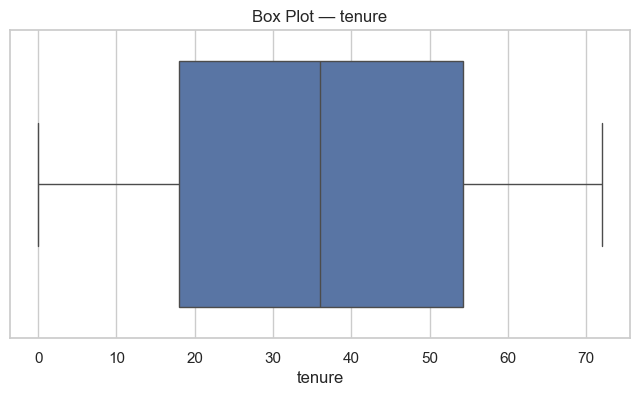

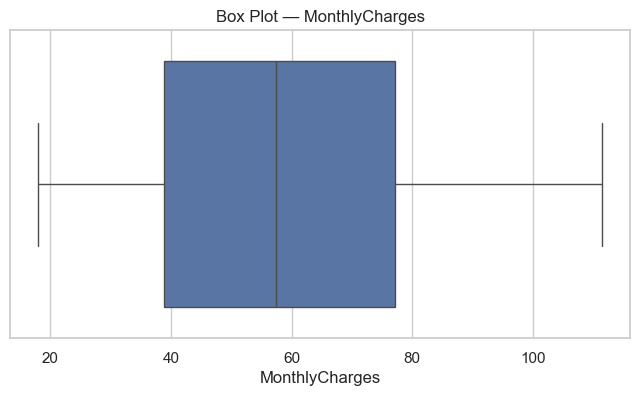

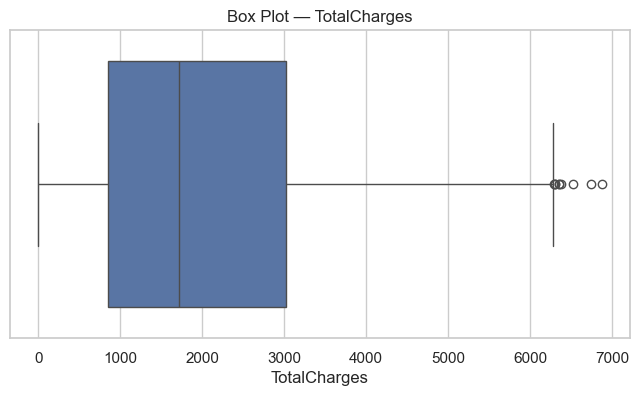

In [53]:
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

for col in num_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=data[col])
    plt.title(f"Box Plot — {col}")
    plt.show()


In [54]:
for col in num_cols:
    print(col)
    print(data[col].describe())
    print("Skewness:", data[col].skew())
    print()


tenure
count    1200.000000
mean       36.171667
std        21.127490
min         0.000000
25%        18.000000
50%        36.000000
75%        54.250000
max        72.000000
Name: tenure, dtype: float64
Skewness: -0.015864857556908793

MonthlyCharges
count    1200.000000
mean       56.978958
std        22.738707
min        18.000000
25%        38.805000
50%        57.400000
75%        77.127500
max       111.420000
Name: MonthlyCharges, dtype: float64
Skewness: -0.1283331462100326

TotalCharges
count    1200.000000
mean     2059.877892
std      1512.401433
min         0.000000
25%       846.935000
50%      1718.260000
75%      3024.417500
max      6875.410000
Name: TotalCharges, dtype: float64
Skewness: 0.7646793543678092



### Outlier decision

Do not blindly remove outliers. In telecom churn data, high charges or high total charges can be legitimate customers. We keep valid observations.


## 8. EDA — TARGET DISTRIBUTION

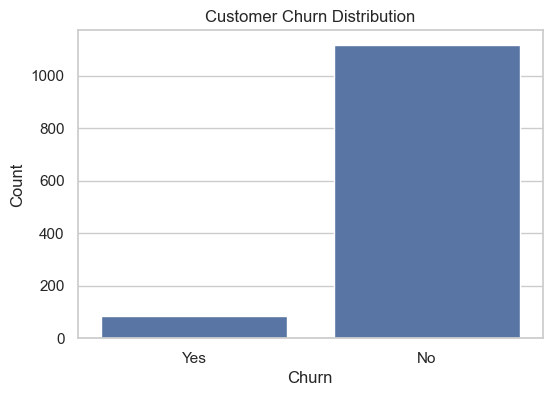

In [55]:
plt.figure(figsize=(6,4))
sns.countplot(data=data, x="Churn")
plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()


## 9. EDA — CATEGORICAL FEATURES

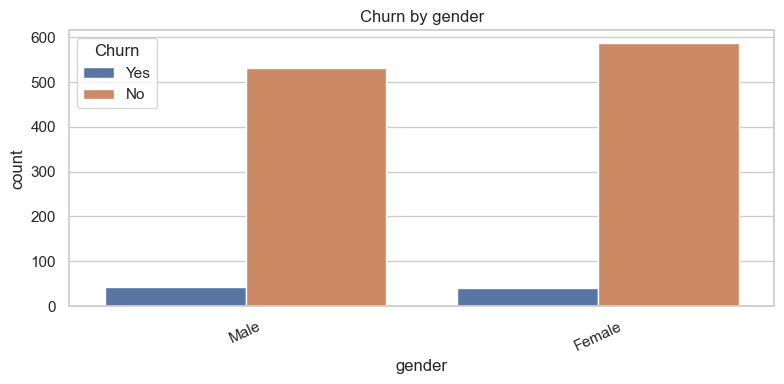

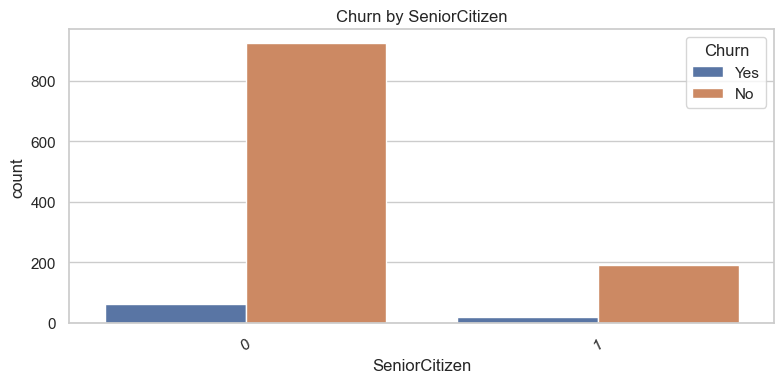

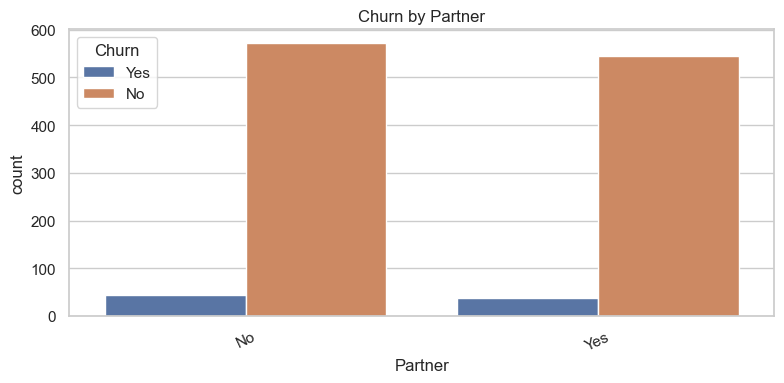

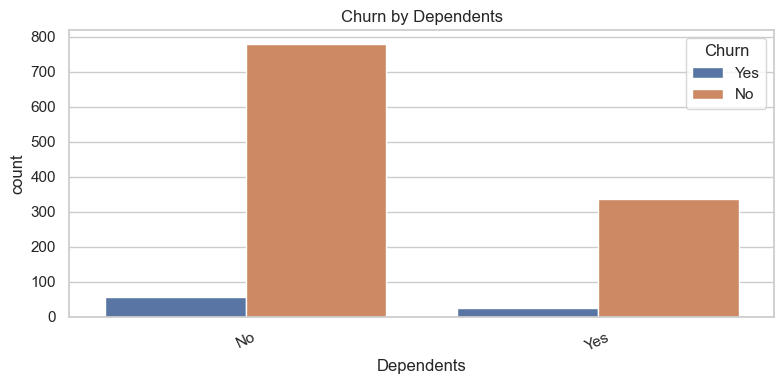

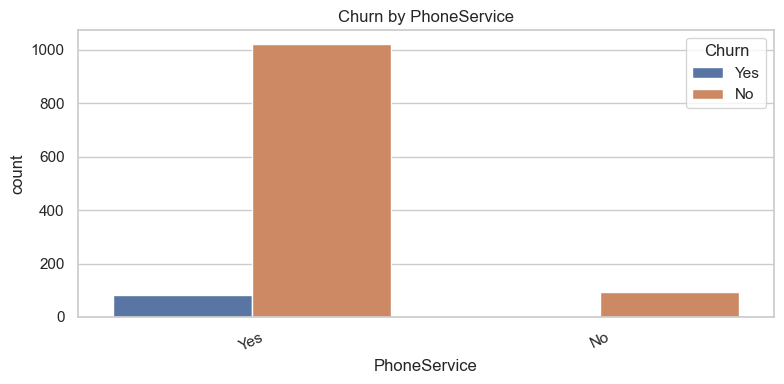

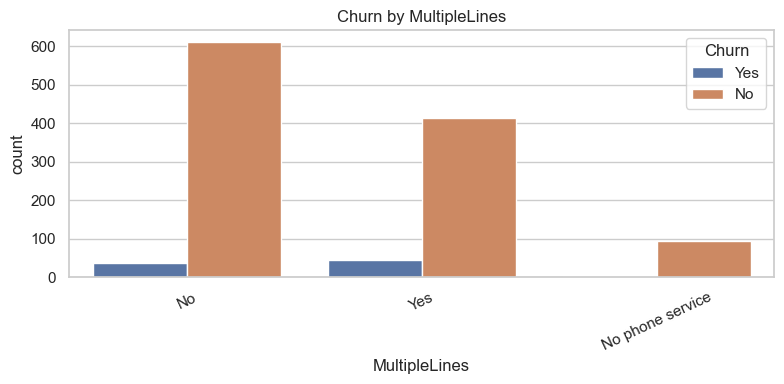

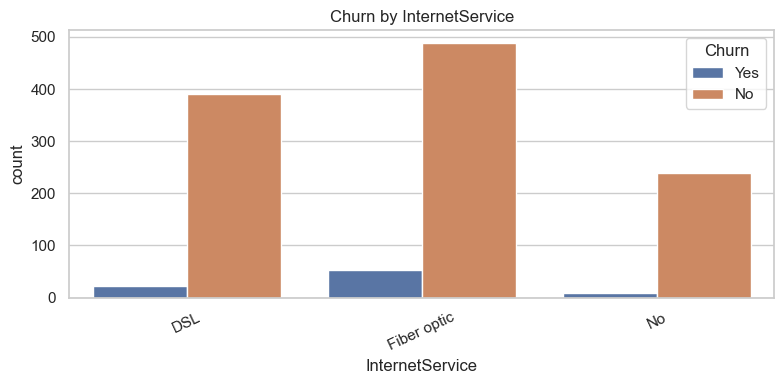

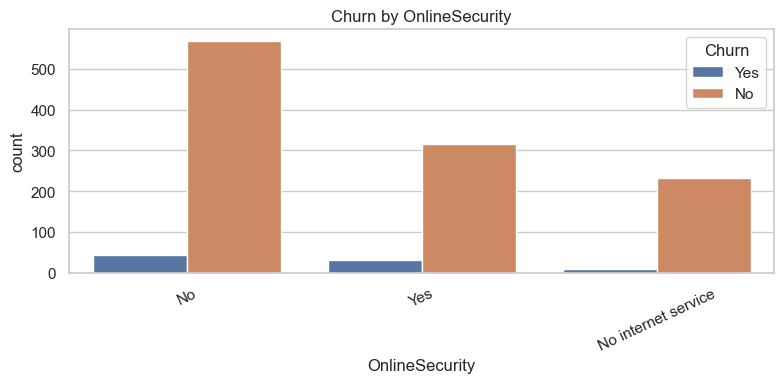

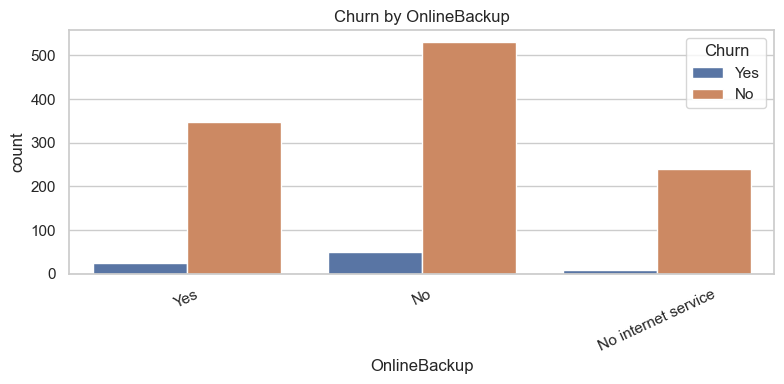

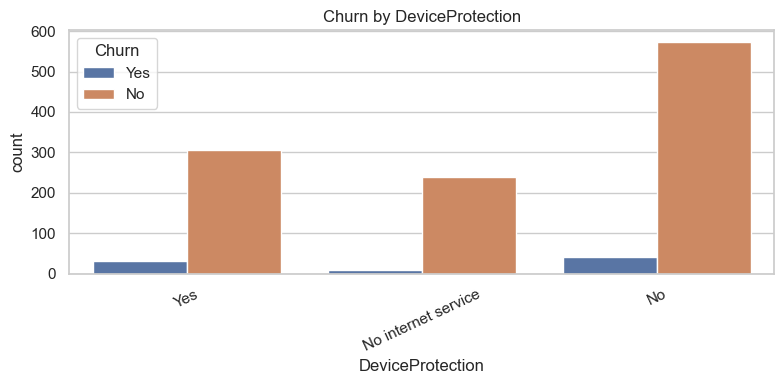

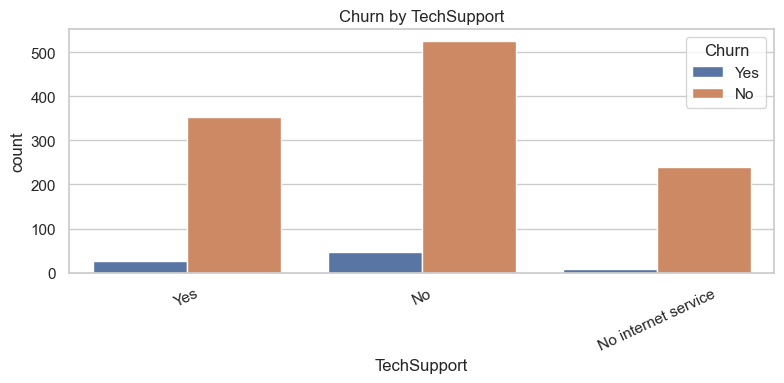

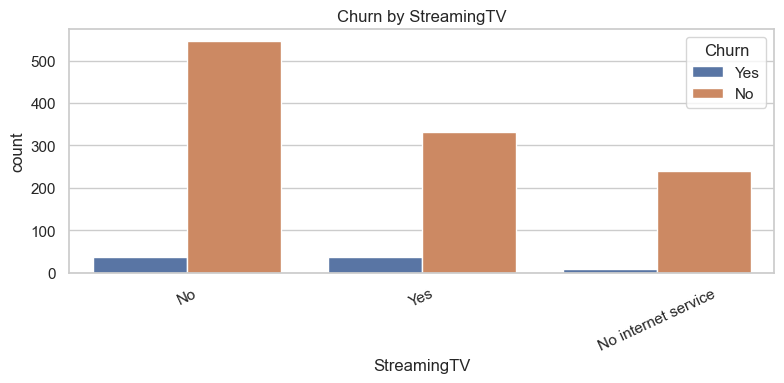

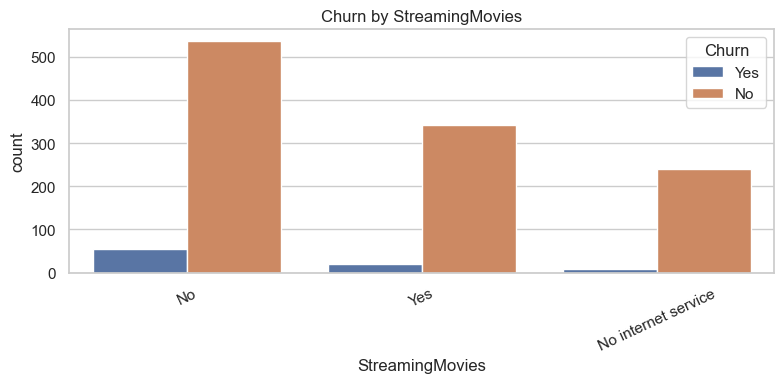

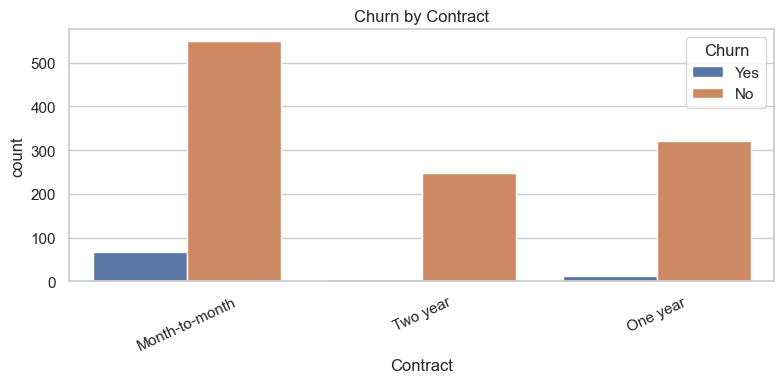

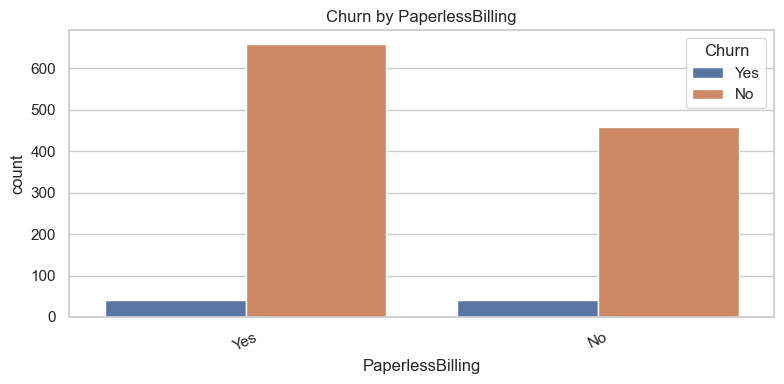

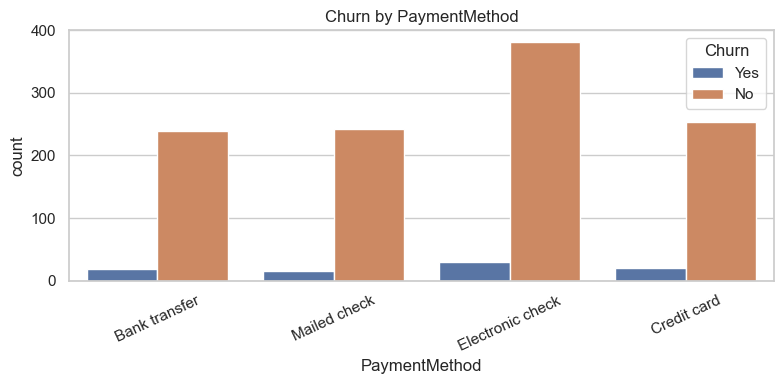

In [56]:
cat_cols = [
    "gender", "SeniorCitizen", "Partner", "Dependents",
    "PhoneService", "MultipleLines", "InternetService",
    "OnlineSecurity", "OnlineBackup", "DeviceProtection",
    "TechSupport", "StreamingTV", "StreamingMovies",
    "Contract", "PaperlessBilling", "PaymentMethod"
]

for col in cat_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(data=data, x=col, hue="Churn")
    plt.title(f"Churn by {col}")
    plt.xticks(rotation=25)
    plt.tight_layout()
    plt.show()


## 10. EDA — NUMERICAL FEATURES

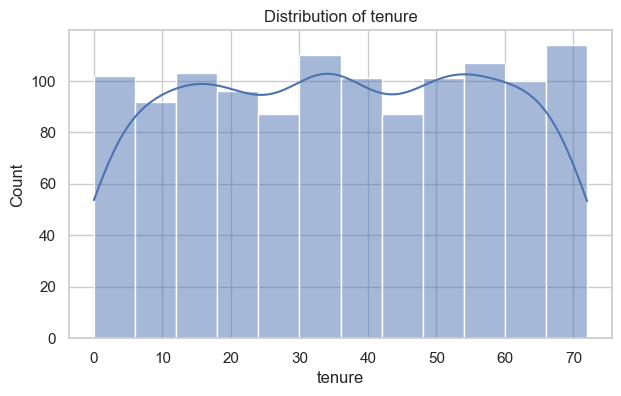

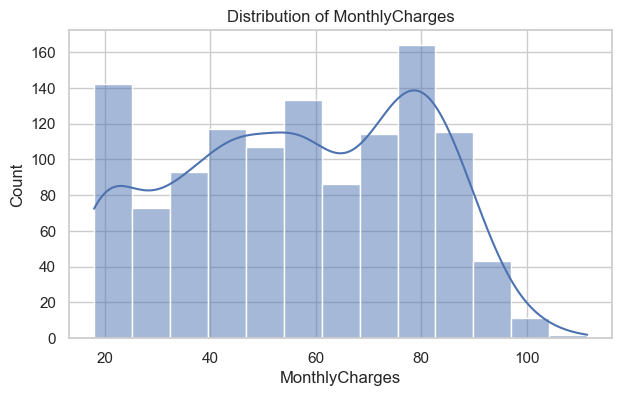

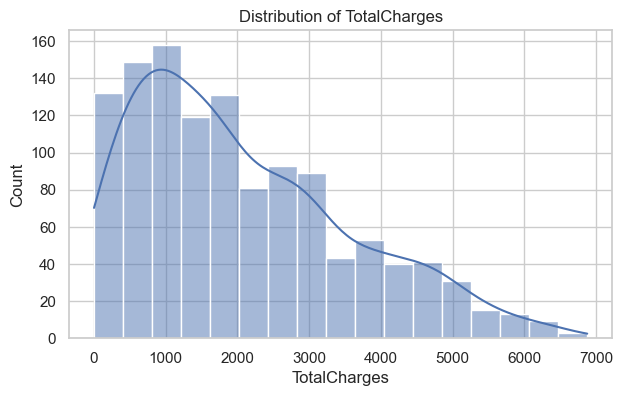

In [57]:
for col in num_cols:
    plt.figure(figsize=(7,4))
    sns.histplot(data[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()


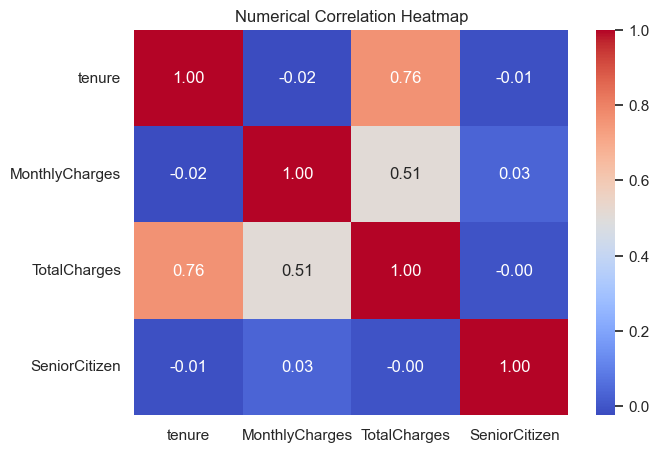

In [58]:
corr = data[num_cols + ["SeniorCitizen"]].corr()

plt.figure(figsize=(7,5))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Numerical Correlation Heatmap")
plt.show()


## 11. FEATURE ENGINEERING

Create the features suggested by the case study:
- Customer Lifetime Value = `tenure × MonthlyCharges`
- Contract score
- Tenure × Contract interaction


In [59]:
contract_map = {
    "Month-to-month": 1,
    "One year": 2,
    "Two year": 3
}

data["ContractScore"] = data["Contract"].map(contract_map)

data["CustomerLifetimeValue"] = (
    data["tenure"] * data["MonthlyCharges"]
)

data["TenureContractScore"] = (
    data["tenure"] * data["ContractScore"]
)

data[[
    "tenure",
    "MonthlyCharges",
    "Contract",
    "ContractScore",
    "CustomerLifetimeValue",
    "TenureContractScore"
]].head()


,tenure,MonthlyCharges,Contract,ContractScore,CustomerLifetimeValue,TenureContractScore
0,49,39.90,Month-to-month,1,1955.10,49
1,14,48.39,Month-to-month,1,677.46,14
2,5,90.98,Month-to-month,1,454.90,5
3,58,22.95,Month-to-month,1,1331.10,58
4,61,27.19,Two year,3,1658.59,183


## 12. REMOVE IDENTIFIER

`customerID` is an identifier and is not used as a predictive feature.


In [60]:
data = data.drop("customerID", axis=1)


## 13. SEPARATE X AND y

**Remember:**

`X` = input/features

`y` = target


In [61]:
X = data.drop("Churn", axis=1)
y = data["Churn"]

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (1200, 22)
y shape: (1200,)


## 14. ENCODE TARGET

For binary classification, convert:
- No → 0
- Yes → 1


In [62]:
y = y.map({"No": 0, "Yes": 1})

print(y.value_counts())


Churn
0    1117
1      83
Name: count, dtype: int64


## 15. TRAIN / VALIDATION SPLIT

Because this version starts with **one CSV**, we create the train/validation split ourselves.

`stratify=y` keeps approximately the same class proportion in both sets.


In [63]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_valid:", X_valid.shape)
print("y_train:", y_train.shape)
print("y_valid:", y_valid.shape)


X_train: (960, 22)
X_valid: (240, 22)
y_train: (960,)
y_valid: (240,)


## 16. IDENTIFY NUMERICAL AND CATEGORICAL FEATURES

In [64]:
binary_cols = [
    "gender",
    "Partner",
    "Dependents",
    "PhoneService",
    "PaperlessBilling"
]

multi_cat_cols = [
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaymentMethod"
]

num_cols = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "ContractScore",
    "CustomerLifetimeValue",
    "TenureContractScore"
]

print("Binary:", binary_cols)
print("Multi-category:", multi_cat_cols)
print("Numerical:", num_cols)


Binary: ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
Multi-category: ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']
Numerical: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'ContractScore', 'CustomerLifetimeValue', 'TenureContractScore']


## 17. BINARY ENCODING

Use this when a categorical column has two meaningful categories.

Examples:
- Male/Female
- Yes/No


In [65]:
binary_map = {
    "Male": 1,
    "Female": 0,
    "Yes": 1,
    "No": 0
}

for col in binary_cols:
    X_train[col] = X_train[col].map(binary_map)
    X_valid[col] = X_valid[col].map(binary_map)

print(X_train[binary_cols].head())


      gender  Partner  Dependents  PhoneService  PaperlessBilling
900        1        0           1             1                 1
491        0        0           1             1                 0
751        1        0           0             1                 1
535        1        0           0             1                 1
1180       0        0           0             1                 1


## 18. ONE-HOT ENCODING

Use one-hot encoding for categorical variables with multiple categories.

`drop_first=True` avoids redundant dummy columns.


In [66]:
X_train = pd.get_dummies(
    X_train,
    columns=multi_cat_cols,
    drop_first=True,
    dtype=int
)

X_valid = pd.get_dummies(
    X_valid,
    columns=multi_cat_cols,
    drop_first=True,
    dtype=int
)

# Make validation columns exactly match training columns
X_valid = X_valid.reindex(
    columns=X_train.columns,
    fill_value=0
)

print("Training shape:", X_train.shape)
print("Validation shape:", X_valid.shape)


Training shape: (960, 33)
Validation shape: (240, 33)


## 19. SCALE NUMERICAL FEATURES

Fit the scaler **only on training data**, then use the same scaler to transform validation data.


In [67]:
scaler = StandardScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_valid[num_cols] = scaler.transform(X_valid[num_cols])

print(X_train[num_cols].head())


      SeniorCitizen    tenure  MonthlyCharges  TotalCharges  ContractScore  \
900       -0.462227 -1.057646        0.070242     -0.794211      -0.880347   
491       -0.462227 -0.156092        0.784461      0.206433       0.371702   
751       -0.462227 -1.105096       -0.973822     -0.891584      -0.880347   
535       -0.462227  0.555662       -0.502742      0.056377      -0.880347   
1180      -0.462227 -0.156092       -0.344076     -0.091056       0.371702   

      CustomerLifetimeValue  TenureContractScore  
900               -0.821768            -0.976841  
491                0.264244             0.079203  
751               -1.061520            -0.997150  
535                0.089939            -0.286351  
1180              -0.287159             0.079203  


## 20. FINAL PREPROCESSING CHECK

In [68]:
print("Object columns remaining:")
print(X_train.select_dtypes(include="object").columns.tolist())

print("Missing values in X_train:", X_train.isnull().sum().sum())
print("Missing values in X_valid:", X_valid.isnull().sum().sum())

print("Train shape:", X_train.shape)
print("Validation shape:", X_valid.shape)


Object columns remaining:
[]
Missing values in X_train: 0
Missing values in X_valid: 0
Train shape: (960, 33)
Validation shape: (240, 33)


# 🟢 21. MODEL 1 — LOGISTIC REGRESSION

In [69]:
lr = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_valid)
y_prob_lr = lr.predict_proba(X_valid)[:, 1]

print("Accuracy :", accuracy_score(y_valid, y_pred_lr))
print("Precision:", precision_score(y_valid, y_pred_lr, zero_division=0))
print("Recall   :", recall_score(y_valid, y_pred_lr, zero_division=0))
print("F1 Score :", f1_score(y_valid, y_pred_lr, zero_division=0))
print("ROC-AUC  :", roc_auc_score(y_valid, y_prob_lr))


Accuracy : 0.7
Precision: 0.14285714285714285
Recall   : 0.6470588235294118
F1 Score : 0.23404255319148937
ROC-AUC  : 0.7314692693220786


# 🟢 22. MODEL 2 — DECISION TREE

In [70]:
dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_valid)
y_prob_dt = dt.predict_proba(X_valid)[:, 1]

print("Accuracy :", accuracy_score(y_valid, y_pred_dt))
print("Precision:", precision_score(y_valid, y_pred_dt, zero_division=0))
print("Recall   :", recall_score(y_valid, y_pred_dt, zero_division=0))
print("F1 Score :", f1_score(y_valid, y_pred_dt, zero_division=0))
print("ROC-AUC  :", roc_auc_score(y_valid, y_prob_dt))


Accuracy : 0.85
Precision: 0.14814814814814814
Recall   : 0.23529411764705882
F1 Score : 0.18181818181818182
ROC-AUC  : 0.566077552097072


# 🟢 23. MODEL 3 — RANDOM FOREST

In [71]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_valid)
y_prob_rf = rf.predict_proba(X_valid)[:, 1]

print("Accuracy :", accuracy_score(y_valid, y_pred_rf))
print("Precision:", precision_score(y_valid, y_pred_rf, zero_division=0))
print("Recall   :", recall_score(y_valid, y_pred_rf, zero_division=0))
print("F1 Score :", f1_score(y_valid, y_pred_rf, zero_division=0))
print("ROC-AUC  :", roc_auc_score(y_valid, y_prob_rf))


Accuracy : 0.925
Precision: 0.0
Recall   : 0.0
F1 Score : 0.0
ROC-AUC  : 0.7466367713004484


## 24. MODEL COMPARISON

In [72]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_valid, y_pred_lr),
        accuracy_score(y_valid, y_pred_dt),
        accuracy_score(y_valid, y_pred_rf)
    ],
    "Precision": [
        precision_score(y_valid, y_pred_lr, zero_division=0),
        precision_score(y_valid, y_pred_dt, zero_division=0),
        precision_score(y_valid, y_pred_rf, zero_division=0)
    ],
    "Recall": [
        recall_score(y_valid, y_pred_lr, zero_division=0),
        recall_score(y_valid, y_pred_dt, zero_division=0),
        recall_score(y_valid, y_pred_rf, zero_division=0)
    ],
    "F1": [
        f1_score(y_valid, y_pred_lr, zero_division=0),
        f1_score(y_valid, y_pred_dt, zero_division=0),
        f1_score(y_valid, y_pred_rf, zero_division=0)
    ],
    "ROC_AUC": [
        roc_auc_score(y_valid, y_prob_lr),
        roc_auc_score(y_valid, y_prob_dt),
        roc_auc_score(y_valid, y_prob_rf)
    ]
})

display(comparison.sort_values("F1", ascending=False).round(4))


,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.700,0.1429,0.6471,0.2340,0.7315
1,Decision Tree,0.850,0.1481,0.2353,0.1818,0.5661
2,Random Forest,0.925,0.0000,0.0000,0.0000,0.7466


## 25. CONFUSION MATRIX — EXAMPLE FINAL MODEL

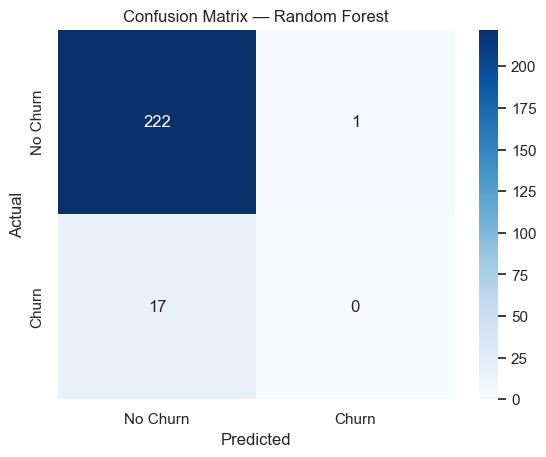

              precision    recall  f1-score   support

    No Churn       0.93      1.00      0.96       223
       Churn       0.00      0.00      0.00        17

    accuracy                           0.93       240
   macro avg       0.46      0.50      0.48       240
weighted avg       0.86      0.93      0.89       240



In [73]:
cm = confusion_matrix(y_valid, y_pred_rf)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Random Forest")
plt.show()

print(classification_report(
    y_valid,
    y_pred_rf,
    target_names=["No Churn", "Churn"],
    zero_division=0
))


# 🟣 26. HYPERPARAMETER TUNING — GRIDSEARCHCV

Tune Random Forest.

During an exam, if time is limited, use a smaller grid.


In [74]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

grid_rf = GridSearchCV(
    estimator=RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ),
    param_grid=param_grid,
    scoring="f1",
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid_rf.fit(X_train, y_train)

print("Best parameters:")
print(grid_rf.best_params_)

print("Best CV F1:", grid_rf.best_score_)


Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best parameters:
{'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best CV F1: 0.0


## 27. EVALUATE TUNED MODEL

In [75]:
best_rf = grid_rf.best_estimator_

y_pred_best_rf = best_rf.predict(X_valid)
y_prob_best_rf = best_rf.predict_proba(X_valid)[:, 1]

print("Accuracy :", accuracy_score(y_valid, y_pred_best_rf))
print("Precision:", precision_score(y_valid, y_pred_best_rf, zero_division=0))
print("Recall   :", recall_score(y_valid, y_pred_best_rf, zero_division=0))
print("F1 Score :", f1_score(y_valid, y_pred_best_rf, zero_division=0))
print("ROC-AUC  :", roc_auc_score(y_valid, y_prob_best_rf))

print("\nClassification Report:")
print(classification_report(
    y_valid,
    y_pred_best_rf,
    target_names=["No Churn", "Churn"],
    zero_division=0
))


Accuracy : 0.9166666666666666
Precision: 0.0
Recall   : 0.0
F1 Score : 0.0
ROC-AUC  : 0.7231601160643629

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.93      0.99      0.96       223
       Churn       0.00      0.00      0.00        17

    accuracy                           0.92       240
   macro avg       0.46      0.49      0.48       240
weighted avg       0.86      0.92      0.89       240



# 🟢 28. FEATURE IMPORTANCE

,Feature,Importance
7,MonthlyCharges,0.135978
10,CustomerLifetimeValue,0.129267
11,TenureContractScore,0.119495
8,TotalCharges,0.110518
4,tenure,0.107475
25,StreamingTV_Yes,0.029062
13,MultipleLines_Yes,0.027351
9,ContractScore,0.025244
6,PaperlessBilling,0.021593
21,DeviceProtection_Yes,0.021412


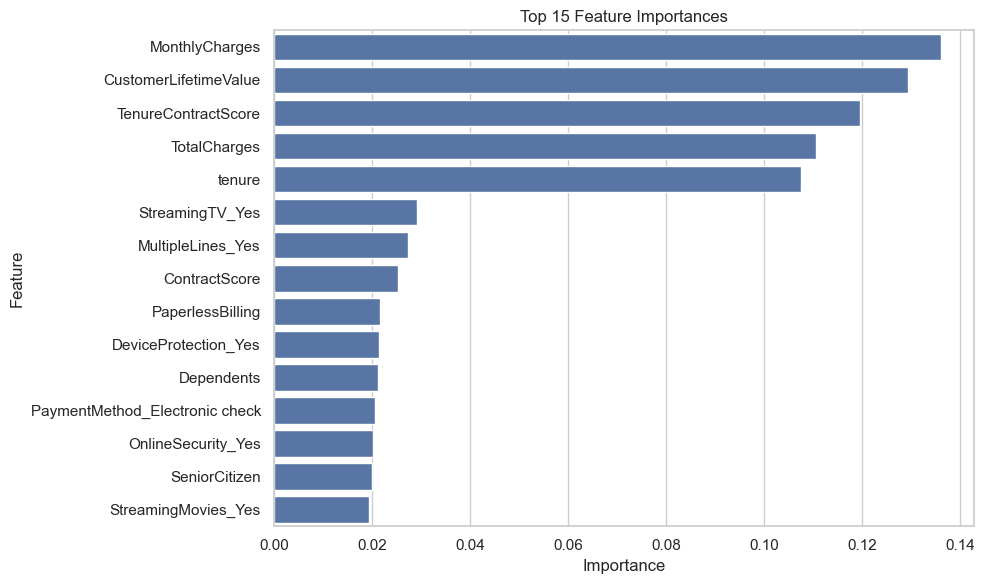

In [76]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_rf.feature_importances_
}).sort_values("Importance", ascending=False)

display(feature_importance.head(15))

plt.figure(figsize=(10,6))
sns.barplot(
    data=feature_importance.head(15),
    x="Importance",
    y="Feature"
)
plt.title("Top 15 Feature Importances")
plt.tight_layout()
plt.show()


# 💾 29. SAVE MODEL AND PREPROCESSING FILES

For deployment, save the model plus the objects needed to transform new user input in the same way as training data.


In [77]:
# Save model
joblib.dump(best_rf, "model.pkl")

# Save scaler
joblib.dump(scaler, "scaler.pkl")

# Save exact feature order
joblib.dump(X_train.columns.tolist(), "feature_columns.pkl")

# Save encoding mappings
joblib.dump(binary_map, "binary_map.pkl")

# Save preprocessing column lists
preprocessing_config = {
    "binary_cols": binary_cols,
    "multi_cat_cols": multi_cat_cols,
    "num_cols": num_cols,
    "contract_map": contract_map
}

joblib.dump(preprocessing_config, "preprocessing_config.pkl")

print("Saved:")
print("model.pkl")
print("scaler.pkl")
print("feature_columns.pkl")
print("binary_map.pkl")
print("preprocessing_config.pkl")


Saved:
model.pkl
scaler.pkl
feature_columns.pkl
binary_map.pkl
preprocessing_config.pkl


# 🌐 30. STREAMLIT DEPLOYMENT

Create `app_streamlit.py`.

The application:
1. accepts customer information
2. performs the same feature engineering
3. applies the same encoding
4. applies the trained scaler
5. aligns columns
6. predicts churn


In [78]:
# Save the Streamlit application to a separate file.
streamlit_app_code = 'import streamlit as st\nimport pandas as pd\nimport numpy as np\nimport joblib\n\nst.set_page_config(\n    page_title="Customer Churn Predictor",\n    page_icon="📊"\n)\n\nst.title("Customer Churn Prediction")\nst.write("Enter customer details to predict churn.")\n\nmodel = joblib.load("model.pkl")\nscaler = joblib.load("scaler.pkl")\nfeature_columns = joblib.load("feature_columns.pkl")\nbinary_map = joblib.load("binary_map.pkl")\nconfig = joblib.load("preprocessing_config.pkl")\n\nbinary_cols = config["binary_cols"]\nmulti_cat_cols = config["multi_cat_cols"]\nnum_cols = config["num_cols"]\ncontract_map = config["contract_map"]\n\ngender = st.selectbox("Gender", ["Male", "Female"])\nsenior_citizen = st.selectbox("Senior Citizen", [0, 1])\npartner = st.selectbox("Partner", ["Yes", "No"])\ndependents = st.selectbox("Dependents", ["Yes", "No"])\ntenure = st.number_input("Tenure (months)", 0, 100, 12)\nphone_service = st.selectbox("Phone Service", ["Yes", "No"])\nmultiple_lines = st.selectbox(\n    "Multiple Lines", ["Yes", "No", "No phone service"]\n)\ninternet_service = st.selectbox(\n    "Internet Service", ["DSL", "Fiber optic", "No"]\n)\nonline_security = st.selectbox(\n    "Online Security", ["Yes", "No", "No internet service"]\n)\nonline_backup = st.selectbox(\n    "Online Backup", ["Yes", "No", "No internet service"]\n)\ndevice_protection = st.selectbox(\n    "Device Protection", ["Yes", "No", "No internet service"]\n)\ntech_support = st.selectbox(\n    "Tech Support", ["Yes", "No", "No internet service"]\n)\nstreaming_tv = st.selectbox(\n    "Streaming TV", ["Yes", "No", "No internet service"]\n)\nstreaming_movies = st.selectbox(\n    "Streaming Movies", ["Yes", "No", "No internet service"]\n)\ncontract = st.selectbox(\n    "Contract", ["Month-to-month", "One year", "Two year"]\n)\npaperless_billing = st.selectbox(\n    "Paperless Billing", ["Yes", "No"]\n)\npayment_method = st.selectbox(\n    "Payment Method",\n    ["Electronic check", "Mailed check", "Bank transfer", "Credit card"]\n)\nmonthly_charges = st.number_input(\n    "Monthly Charges", min_value=0.0, value=70.0\n)\ntotal_charges = st.number_input(\n    "Total Charges", min_value=0.0, value=800.0\n)\n\nif st.button("Predict Churn"):\n\n    input_df = pd.DataFrame([{\n        "gender": gender,\n        "SeniorCitizen": senior_citizen,\n        "Partner": partner,\n        "Dependents": dependents,\n        "tenure": tenure,\n        "PhoneService": phone_service,\n        "MultipleLines": multiple_lines,\n        "InternetService": internet_service,\n        "OnlineSecurity": online_security,\n        "OnlineBackup": online_backup,\n        "DeviceProtection": device_protection,\n        "TechSupport": tech_support,\n        "StreamingTV": streaming_tv,\n        "StreamingMovies": streaming_movies,\n        "Contract": contract,\n        "PaperlessBilling": paperless_billing,\n        "PaymentMethod": payment_method,\n        "MonthlyCharges": monthly_charges,\n        "TotalCharges": total_charges\n    }])\n\n    input_df["ContractScore"] = input_df["Contract"].map(contract_map)\n    input_df["CustomerLifetimeValue"] = (\n        input_df["tenure"] * input_df["MonthlyCharges"]\n    )\n    input_df["TenureContractScore"] = (\n        input_df["tenure"] * input_df["ContractScore"]\n    )\n\n    for col in binary_cols:\n        input_df[col] = input_df[col].map(binary_map)\n\n    input_df = pd.get_dummies(\n        input_df,\n        columns=multi_cat_cols,\n        drop_first=True,\n        dtype=int\n    )\n\n    input_df = input_df.reindex(\n        columns=feature_columns,\n        fill_value=0\n    )\n\n    input_df[num_cols] = scaler.transform(input_df[num_cols])\n\n    prediction = model.predict(input_df)[0]\n    probability = model.predict_proba(input_df)[0, 1]\n\n    st.metric(\n        "Churn Probability",\n        f"{probability * 100:.2f}%"\n    )\n\n    if prediction == 1:\n        st.error("Prediction: Customer is likely to churn.")\n    else:\n        st.success("Prediction: Customer is likely to stay.")\n'
with open('app_streamlit.py', 'w', encoding='utf-8') as f:
    f.write(streamlit_app_code)
print('Created app_streamlit.py')

Created app_streamlit.py


# 🌐 31. FLASK DEPLOYMENT

Create `app_flask.py`.

Use Flask when the question specifically asks for Flask or an API.


In [79]:
flask_app_code = 'from flask import Flask, request, jsonify\nimport pandas as pd\nimport numpy as np\nimport joblib\n\napp = Flask(__name__)\n\nmodel = joblib.load("model.pkl")\nscaler = joblib.load("scaler.pkl")\nfeature_columns = joblib.load("feature_columns.pkl")\nbinary_map = joblib.load("binary_map.pkl")\nconfig = joblib.load("preprocessing_config.pkl")\n\nbinary_cols = config["binary_cols"]\nmulti_cat_cols = config["multi_cat_cols"]\nnum_cols = config["num_cols"]\ncontract_map = config["contract_map"]\n\n\ndef preprocess_input(data):\n\n    df = pd.DataFrame([data])\n\n    df["ContractScore"] = df["Contract"].map(contract_map)\n\n    df["CustomerLifetimeValue"] = (\n        df["tenure"] * df["MonthlyCharges"]\n    )\n\n    df["TenureContractScore"] = (\n        df["tenure"] * df["ContractScore"]\n    )\n\n    for col in binary_cols:\n        df[col] = df[col].map(binary_map)\n\n    df = pd.get_dummies(\n        df,\n        columns=multi_cat_cols,\n        drop_first=True,\n        dtype=int\n    )\n\n    df = df.reindex(\n        columns=feature_columns,\n        fill_value=0\n    )\n\n    df[num_cols] = scaler.transform(df[num_cols])\n\n    return df\n\n\n@app.route("/")\ndef home():\n    return """\n    <h1>Customer Churn Prediction API</h1>\n    <p>Send customer data to POST /predict</p>\n    """\n\n\n@app.route("/predict", methods=["POST"])\ndef predict():\n\n    data = request.get_json()\n\n    X_input = preprocess_input(data)\n\n    prediction = int(model.predict(X_input)[0])\n    probability = float(\n        model.predict_proba(X_input)[0, 1]\n    )\n\n    return jsonify({\n        "prediction": "Yes" if prediction == 1 else "No",\n        "churn_probability": round(probability, 4)\n    })\n\n\nif __name__ == "__main__":\n    app.run(debug=True)\n'
with open('app_flask.py', 'w', encoding='utf-8') as f:
    f.write(flask_app_code)
print('Created app_flask.py')

Created app_flask.py


# 🧠 32. EXAM QUICK WORKFLOW

### If the question gives ONE CSV

Use:

```text
1. pd.read_csv()
2. shape / info / describe()
3. missing values
4. duplicates
5. blank values
6. numeric conversion
7. missing-value treatment
8. outlier check
9. EDA
10. feature engineering
11. drop ID
12. X and y
13. target encoding
14. train_test_split()
15. binary encoding
16. one-hot encoding
17. reindex validation columns
18. StandardScaler
19. 3 models
20. metrics
21. comparison
22. GridSearchCV
23. final model
24. feature importance
25. save .pkl
26. Streamlit OR Flask
```

### Important code to recognize

**Remove column:**
```python
X = data.drop("Churn", axis=1)
```

**Split:**
```python
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
```

**Make validation columns match training:**
```python
X_valid = X_valid.reindex(
    columns=X_train.columns,
    fill_value=0
)
```

**Scale:**
```python
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_valid[num_cols] = scaler.transform(X_valid[num_cols])
```

**Save model:**
```python
joblib.dump(best_rf, "model.pkl")
```

**Load model:**
```python
model = joblib.load("model.pkl")
```

**Streamlit:**
```bash
streamlit run app_streamlit.py
```

**Flask:**
```bash
python app_flask.py
```

### If the exam gives a separate train/test dataset

Do **not** use this one-CSV split workflow. Use the separate train/test workflow instead.
